In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n = 1000

# ── Build Dataset ──────────────────────────────────────────
df = pd.DataFrame({
    'study_hours'   : np.random.normal(6, 2, n).clip(0, 12),
    'sleep_hours'   : np.random.normal(7, 1.5, n).clip(3, 10),
    'attendance_pct': np.random.normal(75, 15, n).clip(0, 100),
    'prev_score'    : np.random.normal(65, 15, n).clip(0, 100),
    'stress_level'  : np.random.randint(1, 10, n).astype(float),
    'exercise_days' : np.random.randint(0, 7, n).astype(float),
})

score = (
    df['study_hours']    * 4.0 +
    df['attendance_pct'] * 0.3 +
    df['prev_score']     * 0.4 +
    df['sleep_hours']    * 1.5 +
    np.random.normal(0, 5, n)
)
df['result'] = (score > score.median()).astype(int)

X = df.drop('result', axis=1)
y = df['result']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [2]:
# ── Train Gaussian NB ──────────────────────────────────────
gnb = GaussianNB(
    var_smoothing = 1e-9
    # ↑ adds a tiny value to variance
    #   prevents division by zero
    #   when a feature has very low variance in a class
    #   default is fine for most cases
)

gnb.fit(X_train, y_train)
y_pred      = gnb.predict(X_test)
y_pred_prob = gnb.predict_proba(X_test)
# ↑ returns probability for each class
#   shape (n_samples, n_classes) → [[0.3, 0.7], [0.8, 0.2], ...]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Fail', 'Pass']))

Accuracy: 0.87

Classification Report:
              precision    recall  f1-score   support

        Fail       0.87      0.87      0.87       102
        Pass       0.87      0.87      0.87        98

    accuracy                           0.87       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.87      0.87      0.87       200



In [3]:
# ── What the model learned — class statistics ──────────────
print("\nClass Priors (P(class)):")
for i, prior in enumerate(gnb.class_prior_):
    print(f"  Class {i}: {prior:.4f}")
# Class 0 (Fail): 0.50
# Class 1 (Pass): 0.50

print("\nMean per feature per class (μ):")
mean_df = pd.DataFrame(
    gnb.theta_,               # θ = mean for each feature per class
    columns = feature_names,
    index   = ['Fail', 'Pass']
)
print(mean_df.round(2))
# Shows: what average values does each class have per feature
# e.g. Pass students average 7.5 study hours
#      Fail students average 4.5 study hours

print("\nVariance per feature per class (σ²):")
var_df = pd.DataFrame(
    gnb.var_,                 # variance for each feature per class
    columns = feature_names,
    index   = ['Fail', 'Pass']
)
print(var_df.round(2))


Class Priors (P(class)):
  Class 0: 0.4975
  Class 1: 0.5025

Mean per feature per class (μ):
      study_hours  sleep_hours  attendance_pct  prev_score  stress_level  \
Fail         5.01         6.99           70.25       58.04          5.01   
Pass         7.08         7.24           79.76       71.04          4.80   

      exercise_days  
Fail           3.08  
Pass           2.92  

Variance per feature per class (σ²):
      study_hours  sleep_hours  attendance_pct  prev_score  stress_level  \
Fail         2.74         2.21          186.19      193.29          6.48   
Pass         2.77         1.97          163.43      193.21          6.40   

      exercise_days  
Fail           3.96  
Pass           4.12  


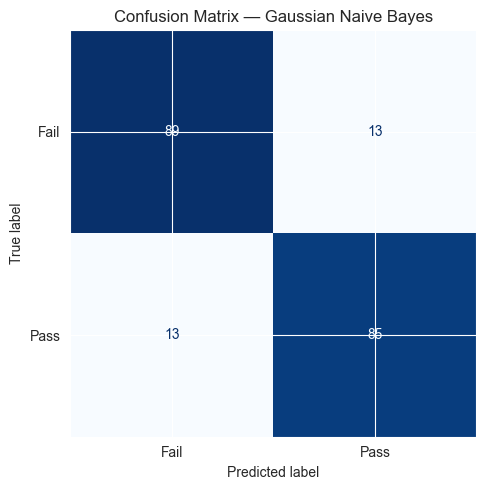

In [4]:
# ── Confusion Matrix ───────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Fail', 'Pass'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title("Confusion Matrix — Gaussian Naive Bayes")
plt.tight_layout()
plt.show()

# Reading the matrix:
#              Predicted Fail   Predicted Pass
# Actual Fail       TN               FP
# Actual Pass       FN               TP

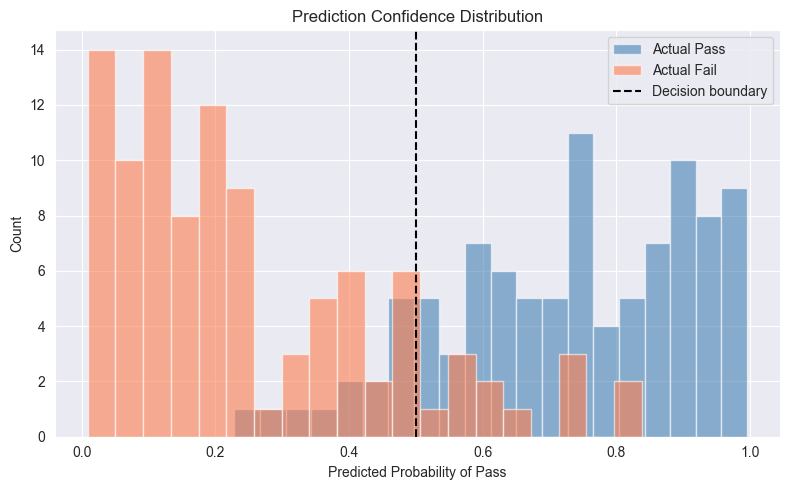

In [5]:
# ── Probability Distribution Plot ─────────────────────────
# Shows how confident the model is in its predictions
plt.figure(figsize=(8, 5))
plt.hist(y_pred_prob[:, 1][y_test == 1], bins=20,
         alpha=0.6, color='steelblue', label='Actual Pass')
plt.hist(y_pred_prob[:, 1][y_test == 0], bins=20,
         alpha=0.6, color='coral',     label='Actual Fail')
plt.axvline(x=0.5, color='black', linestyle='--', label='Decision boundary')
plt.xlabel("Predicted Probability of Pass")
plt.ylabel("Count")
plt.title("Prediction Confidence Distribution")
plt.legend()
plt.tight_layout()
plt.show()

# Well-separated distributions → model is confident
# Overlapping distributions    → model is uncertain near boundary

In [6]:
# ── Cross Validation ──────────────────────────────────────
cv_scores = cross_val_score(gnb, X, y, cv=5, scoring='accuracy')
print(f"\nCross-Val Scores : {cv_scores.round(3)}")
print(f"Mean Accuracy    : {cv_scores.mean():.4f}")
print(f"Std Dev          : {cv_scores.std():.4f}")
# Consistent scores across folds → model is stable


Cross-Val Scores : [0.865 0.855 0.875 0.905 0.855]
Mean Accuracy    : 0.8710
Std Dev          : 0.0185
